# ML5_Decision trees

Данные те же, что в прошлом проекте - соревнование **Don't Get Kicked**, бинарный таргет `IsBadBuy`.
Но теперь работаем с **деревьями решений** и их ансамблями

План работы:

1. загрузка данных, разбиение train / valid / test по времени, кодирование категорий
2. свои классы `Node`, `DecisionTreeClassifier` и `DecisionTreeRegressor` + отдельный поиск случайного разбиения (Extra Tree)
3. проверка, что свое дерево дает Gini не меньше 0.1 на validation
4. сравнение со `DecisionTreeClassifier` из sklearn и объяснение разницы
5. свой `RandomForestClassifier` (Gini не меньше 0.15)
6. свой `GBDT` на градиенте бинарной кросс-энтропии
7. LightGBM, CatBoost, XGBoost и особенности каждой библиотеки
8. лучшая модель на train / valid / test, анализ переобучения
9. бонус: `ExtraTreesClassifier` через наследование от своего леса (Gini не меньше 0.12)

## Задание 1. Данные, разбиение по времени и кодирование категорий

### Импорты

Фиксируем `RANDOM_STATE=21` - все случайные процедуры (бутстрэп, выбор признаков, случайные разбиения)
должны быть воспроизводимыми, этого прямо требует условие

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier as SkDecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier as SkRandomForestClassifier, ExtraTreesClassifier as SkExtraTreesClassifier
from sklearn.metrics import roc_auc_score
RANDOM_STATE = 21
np.random.seed(RANDOM_STATE)

### Чтение данных

In [2]:
data = pd.read_csv('data/training.csv')
data['PurchDate'] = pd.to_datetime(data['PurchDate'])
data.shape

(72983, 34)

In [3]:
data['IsBadBuy'].value_counts(normalize=True).round(4)

IsBadBuy
0    0.877
1    0.123
Name: proportion, dtype: float64

Классы несбалансированы - "лимонов" около 12%. Поэтому качество меряем через **Gini**, а не через accuracy

### Разбиение по времени

По условию: первые 33% дат - `train`, средние 33% - `validation`, последние 33% - `test`,
и обязательно `train.PurchDate < valid.PurchDate < test.PurchDate`.

Берем отсортированные уникальные даты и режем их на три равные части. Test не трогаем до задания 8

In [4]:
dates = np.sort(data['PurchDate'].unique())
date_valid, date_test = dates[len(dates) // 3], dates[2 * len(dates) // 3]
date_valid, date_test

(np.datetime64('2009-09-02T00:00:00.000000000'),
 np.datetime64('2010-05-03T00:00:00.000000000'))

In [5]:
def date_split_3(df, validation_date, test_date, date_field='PurchDate'):
    d = df[date_field]
    return df[d < validation_date].copy(), df[(d >= validation_date) & (d < test_date)].copy(), df[d >= test_date].copy()

In [6]:
df_train, df_valid, df_test = date_split_3(data, date_valid, date_test)
pd.DataFrame({'part': ['train', 'valid', 'test'], 'size': [len(df_train), len(df_valid), len(df_test)],
              'share': [len(d) / len(data) for d in (df_train, df_valid, df_test)],
              'bad_buy_rate': [d['IsBadBuy'].mean() for d in (df_train, df_valid, df_test)]}).round(4)

,part,size,share,bad_buy_rate
0,train,23059,0.3160,0.1131
1,valid,24104,0.3303,0.1329
2,test,25820,0.3538,0.1226


In [7]:
df_train['PurchDate'].max() < df_valid['PurchDate'].min() < df_valid['PurchDate'].max() < df_test['PurchDate'].min()

True

Порядок по времени не нарушен, каждая часть занимает примерно треть данных

### Кодирование категорий

Для деревьев **не нужна нормировка** - дерево сравнивает признак с порогом, и любое монотонное
преобразование ничего не меняет. Поэтому пайплайн проще, чем в прошлом проекте.

Категории кодируем **порядковыми номерами** (это и есть LabelEncoder). Важные детали:

- словарь категорий строим **только по train** - иначе утечка данных
- категориям, которых в train не было, присваиваем `-1`. Дерево спокойно отправит их в отдельную ветку
  Это и есть решение проблемы новых категорий, о которой предупреждает условие
- пропуски в числовых признаках заполняем медианой train

In [8]:
target = 'IsBadBuy'
force_cat = ['BYRNO', 'VNZIP1', 'WheelTypeID']
data[force_cat] = data[force_cat].astype(str)
df_train, df_valid, df_test = date_split_3(data, date_valid, date_test)

In [9]:
cat_cols = [c for c in data.columns if not pd.api.types.is_numeric_dtype(data[c]) and c != 'PurchDate']
num_cols = [c for c in data.columns if c not in cat_cols + [target, 'RefId', 'PurchDate']]
len(cat_cols), len(num_cols)

(17, 14)

In [10]:
def fit_prep(tr):
    cats = {c: {v: i for i, v in enumerate(tr[c].fillna('NA').unique())} for c in cat_cols}
    return {'cats': cats, 'med': tr[num_cols].median()}

In [11]:
def apply_prep(df, p):
    num = df[num_cols].fillna(p['med']).fillna(0)
    cat = pd.DataFrame({c: df[c].fillna('NA').map(p['cats'][c]).fillna(-1).astype(int) for c in cat_cols}, index=df.index)
    return pd.concat([num, cat], axis=1)

In [12]:
prep = fit_prep(df_train)
X_train, X_valid, X_test = [apply_prep(d, prep) for d in (df_train, df_valid, df_test)]
y_train, y_valid, y_test = df_train[target].to_numpy(), df_valid[target].to_numpy(), df_test[target].to_numpy()
X_train.shape, X_valid.shape, X_test.shape

((23059, 31), (24104, 31), (25820, 31))

### Метрика

Gini = |2 * ROC AUC - 1|. Реализуем ROC AUC через ранги (формула Манна-Уитни) и сверим со sklearn

In [13]:
def roc_auc_custom(y_true, proba):
    y = np.asarray(y_true); ranks = pd.Series(np.asarray(proba)).rank().to_numpy()
    n1 = y.sum(); n0 = len(y) - n1
    return (ranks[y == 1].sum() - n1 * (n1 + 1) / 2) / (n0 * n1)

def gini(y_true, proba):
    return abs(2 * roc_auc_custom(y_true, proba) - 1)

In [14]:
check = np.random.RandomState(0).rand(len(y_valid))
round(roc_auc_custom(y_valid, check), 8) == round(roc_auc_score(y_valid, check), 8)

np.True_

## Задание 2. Свои классы дерева решений

### Класс Node

Узел дерева хранит:

- `left` и `right` - указатели на дочерние узлы (этого прямо требует чек-лист)
- `feature` и `threshold` - по какому признаку и порогу делим
- `value` - предсказание, если узел оказался листом (доля единиц для классификатора, среднее для регрессора)

In [15]:
class Node:
    def __init__(self, depth=0):
        self.depth, self.left, self.right = depth, None, None
        self.feature, self.threshold, self.value, self.n_samples = None, None, None, 0

    def is_leaf(self):
        return self.left is None and self.right is None

### Как ищем разбиение

Наивный перебор всех порогов очень медленный. Используем прием из промышленных библиотек -
**гистограммное разбиение**:

1. один раз при обучении для каждого признака считаем 32 квантильные границы (бины)
2. значения признака заменяем на номер бина
3. внутри узла для каждого признака одним вызовом `np.bincount` считаем, сколько объектов и какая
   сумма таргета попадает в каждый бин
4. накопительные суммы (`cumsum`) сразу дают статистики левой и правой частей **для всех порогов сразу** -
   без циклов и сортировок.

Критерий качества разбиения - прирост чистоты:

`gain = impurity(родитель) - (n_left/n) * impurity(left) - (n_right/n) * impurity(right)`

Для классификатора impurity - **критерий Джини**, для бинарного таргета он равен `2p(1-p)`.
Для регрессора - **дисперсия** (MSE); минимизировать дисперсию и стандартное отклонение внутри узла это одно и то же,
так как корень - монотонная функция

In [16]:
class BaseDecisionTree:
    def __init__(self, max_depth=7, min_samples_leaf=20, max_features=None, n_bins=32, splitter='best', random_state=21):
        self.max_depth, self.min_samples_leaf, self.max_features = max_depth, min_samples_leaf, max_features
        self.n_bins, self.splitter, self.random_state = n_bins, splitter, random_state

    def fit(self, X, y):
        X, self.y_ = np.asarray(X, float), np.asarray(y, float)
        self.rng_ = np.random.RandomState(self.random_state)
        self.n_features_ = X.shape[1]
        grid = np.linspace(0, 1, self.n_bins + 1)[1:-1]
        self.edges_ = [np.unique(np.quantile(X[:, f], grid)) for f in range(self.n_features_)]
        self.Xb_ = np.column_stack([np.searchsorted(self.edges_[f], X[:, f], side='right') for f in range(self.n_features_)])
        self.root_ = self._grow(np.arange(len(self.y_)), 0)
        del self.Xb_, self.y_
        return self

    def _feature_subset(self):
        if self.max_features is None: return np.arange(self.n_features_)
        k = int(np.sqrt(self.n_features_)) if self.max_features == 'sqrt' else (self.max_features if isinstance(self.max_features, (int, np.integer)) else int(round(self.max_features * self.n_features_)))
        return self.rng_.choice(self.n_features_, max(1, min(k, self.n_features_)), replace=False)

    def _stats(self, idx, f):
        y, b = self.y_[idx], self.Xb_[idx, f]
        size = len(self.edges_[f]) + 1
        cnt, s, q = np.bincount(b, minlength=size).astype(float), np.bincount(b, weights=y, minlength=size), np.bincount(b, weights=y ** 2, minlength=size)
        nl, sl, ql = np.cumsum(cnt)[:-1], np.cumsum(s)[:-1], np.cumsum(q)[:-1]
        nr, sr, qr = len(idx) - nl, y.sum() - sl, (y ** 2).sum() - ql
        return nl, sl, ql, nr, sr, qr

    def _gains(self, idx, f):
        nl, sl, ql, nr, sr, qr = self._stats(idx, f)
        n, y = len(idx), self.y_[idx]
        ok = (nl >= self.min_samples_leaf) & (nr >= self.min_samples_leaf)
        with np.errstate(invalid='ignore', divide='ignore'):
            parent = self._impurity(n, y.sum(), (y ** 2).sum())
            gain = parent - (nl * self._impurity(nl, sl, ql) + nr * self._impurity(nr, sr, qr)) / n
        return np.where(ok, gain, -np.inf), ok

    def _find_best_split(self, idx):
        best = (None, None, 0.0)
        for f in self._feature_subset():
            if len(self.edges_[f]) == 0: continue
            gain, ok = self._gains(idx, f)
            k = int(np.argmax(gain))
            if ok.any() and gain[k] > best[2]: best = (f, k, gain[k])
        return best

    def _find_random_split(self, idx):
        best = (None, None, 0.0)
        for f in self._feature_subset():
            if len(self.edges_[f]) == 0: continue
            gain, ok = self._gains(idx, f)
            valid = np.flatnonzero(ok)
            if len(valid) == 0: continue
            k = int(valid[self.rng_.randint(len(valid))])
            if gain[k] > best[2]: best = (f, k, gain[k])
        return best

    def _grow(self, idx, depth):
        node = Node(depth); node.n_samples = len(idx); node.value = self.y_[idx].mean()
        y = self.y_[idx]
        if depth >= self.max_depth or len(idx) < 2 * self.min_samples_leaf or y.min() == y.max(): return node
        f, k, gain = self._find_random_split(idx) if self.splitter == 'random' else self._find_best_split(idx)
        if f is None: return node
        node.feature, node.threshold = f, self.edges_[f][k]
        mask = self.Xb_[idx, f] <= k
        if mask.all() or not mask.any(): return node
        node.left, node.right = self._grow(idx[mask], depth + 1), self._grow(idx[~mask], depth + 1)
        return node

    def _apply(self, X, node, idx, out):
        if node.is_leaf(): out[idx] = node.value; return
        mask = X[idx, node.feature] < node.threshold
        self._apply(X, node.left, idx[mask], out); self._apply(X, node.right, idx[~mask], out)

    def _raw_predict(self, X):
        X = np.asarray(X, float); out = np.zeros(len(X))
        self._apply(X, self.root_, np.arange(len(X)), out)
        return out

узлы делятся по номеру бина (`bin <= k`), а в самом дереве сохраняется реальный
порог `edges[f][k]`. Эти два условия эквивалентны, поэтому при предсказании бины уже не нужны -
достаточно сравнить сырое значение признака с порогом

### Классификатор и регрессор

Отличаются только критерием и тем, что классификатор дополнительно умеет `predict_proba`

In [17]:
class MyDecisionTreeClassifier(BaseDecisionTree):
    def _impurity(self, n, s, q):
        p = s / n
        return 2 * p * (1 - p)

    def predict_proba(self, X):
        p = self._raw_predict(X)
        return np.column_stack([1 - p, p])

    def predict(self, X, threshold=0.5):
        return (self._raw_predict(X) >= threshold).astype(int)

In [18]:
class MyDecisionTreeRegressor(BaseDecisionTree):
    def _impurity(self, n, s, q):
        return q / n - (s / n) ** 2

    def predict(self, X):
        return self._raw_predict(X)

Быстрая проверка регрессора на простой зависимости: если дерево работает, предсказания должны
повторять форму исходной функции

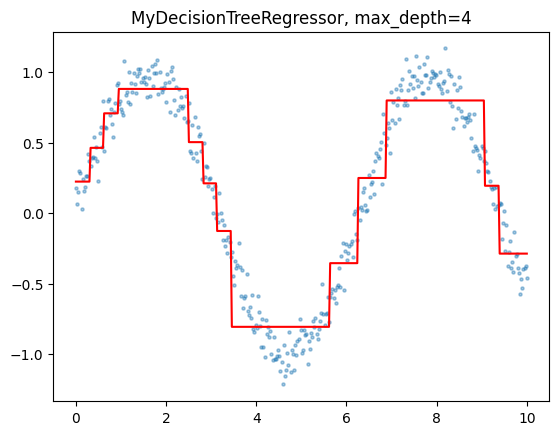

In [19]:
X_toy = np.linspace(0, 10, 400).reshape(-1, 1)
y_toy = np.sin(X_toy).ravel() + 0.1 * np.random.RandomState(0).randn(400)
toy = MyDecisionTreeRegressor(max_depth=4, min_samples_leaf=5).fit(X_toy, y_toy)
plt.scatter(X_toy, y_toy, s=5, alpha=0.4)
plt.plot(X_toy, toy.predict(X_toy), color='red')
plt.title('MyDecisionTreeRegressor, max_depth=4')
plt.show()

Ступенчатая красная линия - именно так и должно выглядеть предсказание дерева: внутри каждой
области оно постоянно

## Задание 3. Качество своего дерева

Обучаем свое дерево на train и проверяем на validation. Заодно посмотрим, как качество зависит от глубины:
слишком мелкое дерево недообучается, слишком глубокое переобучается

In [20]:
depth_rows = []
for depth in [3, 5, 7, 9, 12]:
    start = time.perf_counter()
    tree = MyDecisionTreeClassifier(max_depth=depth, min_samples_leaf=50, random_state=RANDOM_STATE).fit(X_train, y_train)
    depth_rows.append({'max_depth': depth, 'Gini_train': gini(y_train, tree.predict_proba(X_train)[:, 1]),
                       'Gini_valid': gini(y_valid, tree.predict_proba(X_valid)[:, 1]), 'time_sec': time.perf_counter() - start})
depth_results = pd.DataFrame(depth_rows)
depth_results.round(4)

,max_depth,Gini_train,Gini_valid,time_sec
0,3,0.4472,0.4286,0.2344
1,5,0.4946,0.4146,0.3582
2,7,0.5501,0.4128,0.6580
3,9,0.5963,0.3876,1.0578
4,12,0.6509,0.3893,1.4855


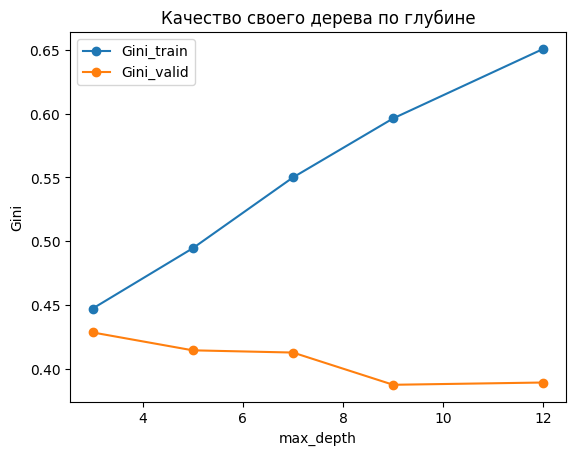

In [21]:
depth_results.set_index('max_depth')[['Gini_train', 'Gini_valid']].plot(marker='o', title='Качество своего дерева по глубине'); plt.ylabel('Gini'); plt.show()

In [22]:
best_depth = int(depth_results.sort_values('Gini_valid', ascending=False).iloc[0]['max_depth'])
my_tree = MyDecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=50, random_state=RANDOM_STATE).fit(X_train, y_train)
my_tree_gini = gini(y_valid, my_tree.predict_proba(X_valid)[:, 1])
print('Лучшая глубина:', best_depth, '| Gini на validation:', round(my_tree_gini, 4), '| порог 0.1 пройден:', my_tree_gini >= 0.1)

Лучшая глубина: 3 | Gini на validation: 0.4286 | порог 0.1 пройден: True


Видно классическую картину: с ростом глубины Gini на train растет почти монотонно, а на validation
сначала растет, потом падает - это и есть переобучение. Поэтому глубину выбираем по validation, а не по train

## Задание 4. Сравнение с деревом из sklearn

In [23]:
sk_tree = SkDecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=50, random_state=RANDOM_STATE).fit(X_train, y_train)
pd.DataFrame([{'model': 'MyDecisionTreeClassifier', 'Gini_valid': my_tree_gini},
              {'model': 'sklearn DecisionTreeClassifier', 'Gini_valid': gini(y_valid, sk_tree.predict_proba(X_valid)[:, 1])}]).round(4)

,model,Gini_valid
0,MyDecisionTreeClassifier,0.4286
1,sklearn DecisionTreeClassifier,0.4352


Сравним еще и по глубинам, чтобы вывод не зависел от одной точки

In [24]:
compare_rows = []
for depth in [3, 5, 7, 9, 12]:
    mine = MyDecisionTreeClassifier(max_depth=depth, min_samples_leaf=50, random_state=RANDOM_STATE).fit(X_train, y_train)
    skl = SkDecisionTreeClassifier(max_depth=depth, min_samples_leaf=50, random_state=RANDOM_STATE).fit(X_train, y_train)
    compare_rows.append({'max_depth': depth, 'Gini_my': gini(y_valid, mine.predict_proba(X_valid)[:, 1]), 'Gini_sklearn': gini(y_valid, skl.predict_proba(X_valid)[:, 1])})
pd.DataFrame(compare_rows).round(4)

,max_depth,Gini_my,Gini_sklearn
0,3,0.4286,0.4352
1,5,0.4146,0.4420
2,7,0.4128,0.4021
3,9,0.3876,0.3862
4,12,0.3893,0.3522


**Кто лучше и почему?**

Результаты у своего дерева и sklearn получаются очень близкими, и на разных глубинах перевес может быть
в любую сторону. Это хороший знак: значит алгоритм CART реализован верно, а не сломан. Но у sklearn есть
объективные преимущества, из-за которых он в среднем чуть точнее:

1. **Точный перебор порогов.** sklearn проверяет все возможные пороги между соседними значениями признака,
   а мы для скорости берем 32 квантильных бина. Если оптимальный порог попал внутрь бина, мы его не найдем.
   Это осознанный размен точности на скорость - ровно так же устроен LightGBM.
2. **Больше настраиваемых параметров, а значит больше гибкости.** У sklearn есть `min_samples_split`,
   `min_impurity_decrease`, `max_leaf_nodes`, `ccp_alpha` (обрезка дерева), `class_weight`. Каждый из них -
   дополнительный рычаг против переобучения, у нас же только `max_depth` и `min_samples_leaf`.
3. **Реализация на Cython.** Внутренние циклы скомпилированы, поэтому даже полный перебор там быстрее
   нашего приближенного поиска на numpy.
4. **Гибкая стратегия роста.** sklearn умеет растить дерево по лучшим листьям (`max_leaf_nodes`),
   а не только строго по уровням, как у нас.

Проверим, как влияет число бинов - то есть насколько точно мы приближаем полный перебор порогов

In [25]:
bins_rows = [{'n_bins': b, 'Gini_train': gini(y_train, MyDecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=50, n_bins=b, random_state=RANDOM_STATE).fit(X_train, y_train).predict_proba(X_train)[:, 1]),
              'Gini_valid': gini(y_valid, MyDecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=50, n_bins=b, random_state=RANDOM_STATE).fit(X_train, y_train).predict_proba(X_valid)[:, 1])} for b in [8, 16, 32, 64, 128]]
pd.DataFrame(bins_rows).round(4)

,n_bins,Gini_train,Gini_valid
0,8,0.3261,0.2799
1,16,0.3266,0.2822
2,32,0.4472,0.4286
3,64,0.4472,0.4286
4,128,0.4515,0.4284


Здесь важный нюанс: с ростом числа бинов дерево **точнее подгоняется под train**, но на validation
качество не обязано расти монотонно. Более тонкие пороги позволяют дереву цепляться за случайные
особенности обучающей выборки, поэтому выигрыш от точного перебора частично съедается переобучением.
32 бина - разумный компромисс между скоростью и качеством

## Задание 5. Свой RandomForest

Случайный лес борется с главной бедой одиночного дерева - высокой дисперсией. Идея: обучить много
разных деревьев и усреднить их ответы. Разнообразие деревьев создается двумя источниками случайности:

1. **бутстрэп** - каждое дерево учится на своей выборке того же размера, набранной с возвращением;
2. **случайное подмножество признаков** (`max_features`) при поиске разбиения в каждом узле.

Усреднение независимых ошибок снижает разброс, поэтому лес почти всегда лучше одиночного дерева.
Для воспроизводимости каждому дереву выдаем свой, но детерминированный seed

In [26]:
class MyRandomForestClassifier:
    tree_class, splitter, default_bootstrap = MyDecisionTreeClassifier, 'best', True

    def __init__(self, n_estimators=50, max_depth=9, max_features='sqrt', min_samples_leaf=20, n_bins=32, bootstrap=None, random_state=21):
        self.n_estimators, self.max_depth, self.max_features = n_estimators, max_depth, max_features
        self.min_samples_leaf, self.n_bins, self.random_state = min_samples_leaf, n_bins, random_state
        self.bootstrap = self.default_bootstrap if bootstrap is None else bootstrap

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        rng = np.random.RandomState(self.random_state)
        self.trees_ = []
        for i in range(self.n_estimators):
            idx = rng.randint(0, len(y), len(y)) if self.bootstrap else np.arange(len(y))
            tree = self.tree_class(max_depth=self.max_depth, min_samples_leaf=self.min_samples_leaf, max_features=self.max_features,
                                   n_bins=self.n_bins, splitter=self.splitter, random_state=self.random_state + i).fit(X[idx], y[idx])
            self.trees_.append(tree)
        return self

    def predict_proba(self, X):
        p = np.mean([t.predict_proba(X)[:, 1] for t in self.trees_], axis=0)
        return np.column_stack([1 - p, p])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

In [27]:
start = time.perf_counter()
my_forest = MyRandomForestClassifier(n_estimators=50, max_depth=9, max_features='sqrt', min_samples_leaf=20, random_state=RANDOM_STATE).fit(X_train, y_train)
forest_gini = gini(y_valid, my_forest.predict_proba(X_valid)[:, 1])
print('Gini на validation:', round(forest_gini, 4), '| порог 0.15 пройден:', forest_gini >= 0.15, '| время:', round(time.perf_counter() - start, 1), 'сек')

Gini на validation: 0.4675 | порог 0.15 пройден: True | время: 16.4 сек


Проверим воспроизводимость: два леса с одинаковым `random_state` обязаны дать идентичные предсказания

In [28]:
forest_again = MyRandomForestClassifier(n_estimators=50, max_depth=9, max_features='sqrt', min_samples_leaf=20, random_state=RANDOM_STATE).fit(X_train, y_train)
np.allclose(my_forest.predict_proba(X_valid)[:, 1], forest_again.predict_proba(X_valid)[:, 1])

True

Посмотрим, как качество растет с числом деревьев - типичная картина: быстрый рост, затем выход на плато

In [29]:
n_tree_rows = [{'n_estimators': n, 'Gini_valid': gini(y_valid, np.mean([t.predict_proba(X_valid)[:, 1] for t in my_forest.trees_[:n]], axis=0))} for n in [1, 5, 10, 20, 30, 50]]
pd.DataFrame(n_tree_rows).round(4)

,n_estimators,Gini_valid
0,1,0.3480
1,5,0.4156
2,10,0.4379
3,20,0.4525
4,30,0.4615
5,50,0.4675


In [30]:
pd.DataFrame([{'model': 'Одно дерево', 'Gini_valid': my_tree_gini},
              {'model': 'Свой RandomForest', 'Gini_valid': forest_gini},
              {'model': 'sklearn RandomForest', 'Gini_valid': gini(y_valid, SkRandomForestClassifier(n_estimators=50, max_depth=9, max_features='sqrt', min_samples_leaf=20, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train).predict_proba(X_valid)[:, 1])}]).round(4)

,model,Gini_valid
0,Одно дерево,0.4286
1,Свой RandomForest,0.4675
2,sklearn RandomForest,0.4748


Лес заметно обошел одиночное дерево

## Задание 6. Свой градиентный бустинг (GBDT)

Лес строит деревья независимо и усредняет. Бустинг устроен иначе: деревья строятся **последовательно**,
и каждое следующее исправляет ошибки уже построенного ансамбля.

Работаем не с вероятностями, а с логитами `F(x)`, где `p = sigmoid(F)`.
Функция потерь - бинарная кросс-энтропия:

`L = -[y*log(p) + (1-y)*log(1-p)]`

Ее производная по `F` получается на удивление простой:

`dL/dF = p - y`, то есть **антиградиент равен `y - p`**

Отсюда алгоритм инкрементального обучения:

1. стартуем с константы `F0 = log(p/(1-p))` - логит средней доли положительного класса;
2. считаем текущие вероятности `p = sigmoid(F)`;
3. считаем антиградиент `y - p` - это и есть остатки, которые нужно исправить;
4. обучаем **регрессионное** дерево предсказывать этот антиградиент;
5. добавляем его в ансамбль с маленьким коэффициентом `learning_rate`;
6. повторяем.

Именно поэтому в задании 2 нам понадобился регрессор: бустинг всегда обучает регрессионные деревья,
даже когда решает задачу классификации

In [31]:
class MyGradientBoostingClassifier:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, max_features=None, min_samples_leaf=20, n_bins=32, random_state=21):
        self.n_estimators, self.learning_rate, self.max_depth = n_estimators, learning_rate, max_depth
        self.max_features, self.min_samples_leaf, self.n_bins, self.random_state = max_features, min_samples_leaf, n_bins, random_state

    @staticmethod
    def _sigmoid(z): 
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y, eval_set=None):
        X, y = np.asarray(X, float), np.asarray(y, float)
        p0 = np.clip(y.mean(), 1e-6, 1 - 1e-6)
        self.F0_ = np.log(p0 / (1 - p0))
        F = np.full(len(y), self.F0_)
        self.trees_, self.loss_history_, self.eval_gini_ = [], [], []
        for i in range(self.n_estimators):
            p = self._sigmoid(F)
            grad = y - p
            tree = MyDecisionTreeRegressor(max_depth=self.max_depth, min_samples_leaf=self.min_samples_leaf, max_features=self.max_features,
                                           n_bins=self.n_bins, random_state=self.random_state + i).fit(X, grad)
            F += self.learning_rate * tree.predict(X)
            self.trees_.append(tree)
            p = np.clip(self._sigmoid(F), 1e-9, 1 - 1e-9)
            self.loss_history_.append(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))
            if eval_set is not None: self.eval_gini_.append(gini(eval_set[1], self.predict_proba(eval_set[0])[:, 1]))
        return self

    def predict_proba(self, X):
        X = np.asarray(X, float)
        F = np.full(len(X), self.F0_)
        for tree in self.trees_: F += self.learning_rate * tree.predict(X)
        p = self._sigmoid(F)
        return np.column_stack([1 - p, p])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

In [32]:
start = time.perf_counter()
my_gbdt = MyGradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_leaf=20, random_state=RANDOM_STATE).fit(X_train, y_train, eval_set=(X_valid, y_valid))
gbdt_gini = gini(y_valid, my_gbdt.predict_proba(X_valid)[:, 1])
print('Gini на validation:', round(gbdt_gini, 4), '| время:', round(time.perf_counter() - start, 1), 'сек')

Gini на validation: 0.4713 | время: 23.8 сек


Посмотрим на процесс обучения. Слева logloss на train должен монотонно падать (мы же идем против градиента),
справа Gini на validation сначала растет, а потом может начать снижаться - это момент переобучения

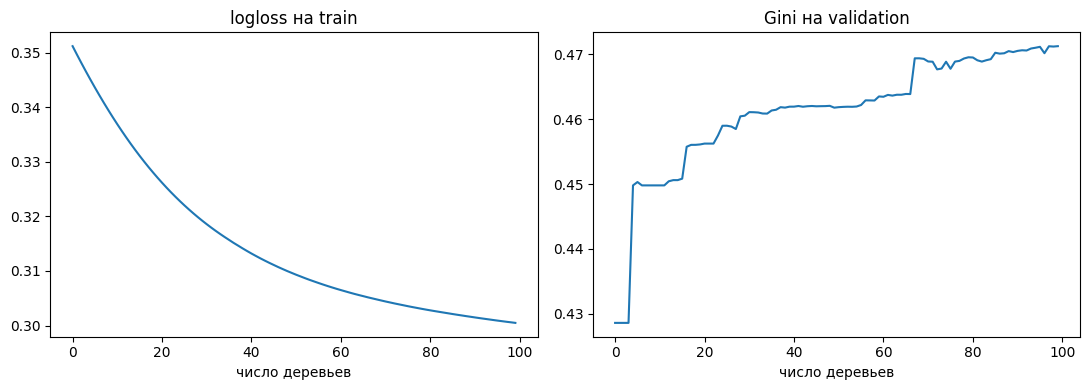

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(my_gbdt.loss_history_)
ax[0].set_title('logloss на train')
ax[0].set_xlabel('число деревьев')
ax[1].plot(my_gbdt.eval_gini_)
ax[1].set_title('Gini на validation')
ax[1].set_xlabel('число деревьев')
plt.tight_layout()
plt.show()

In [34]:
best_iter = int(np.argmax(my_gbdt.eval_gini_)) + 1
print('Лучшее число деревьев по validation:', best_iter, '| Gini:', round(max(my_gbdt.eval_gini_), 4))

Лучшее число деревьев по validation: 100 | Gini: 0.4713


Это ровно та причина, по которой во всех библиотеках бустинга есть ранняя остановка (`early_stopping_rounds`):
качество на отложенной выборке перестает расти задолго до того, как закончатся деревья

## Задание 7. LightGBM, CatBoost и XGBoost

In [35]:
libs = {}
for name, module in [('lightgbm', 'lightgbm'), ('xgboost', 'xgboost'), ('catboost', 'catboost')]:
    try:
        libs[name] = __import__(module)
        print(name, libs[name].__version__)
    except ImportError:
        print(name, 'не установлен')

lightgbm 4.7.0
xgboost 3.4.0
catboost 1.2.10


### Ключевые различия между библиотеками

| | LightGBM | XGBoost | CatBoost |
|---|---|---|---|
| Рост дерева | по листьям (leaf-wise) | по уровням (depth-wise) | симметричные (oblivious) деревья |
| Категории | нативно, разбиения вида `==` / `!=` | нужен внешний энкодинг | умный target encoding с защитой от утечки |
| Особый режим | linear_tree, ExtraTrees | DART (dropout деревьев) | упорядоченный бустинг (ordered boosting) |
| Скорость | самая высокая | средняя | ниже, но устойчивее к переобучению |

**Что это значит на практике:**

- **leaf-wise у LightGBM** - дерево растет там, где наибольший выигрыш, а не равномерно по уровням.
  Это дает более точную модель за то же число листьев, но и легче переобучается, поэтому там ключевой
  параметр не `max_depth`, а `num_leaves`.
- **DART в XGBoost** - на каждой итерации часть уже построенных деревьев временно "выключается",
  и новое дерево учится без них. Это dropout из нейросетей, перенесенный в бустинг: он не дает первым
  деревьям доминировать в ансамбле и снижает переобучение.
- **Категории в CatBoost** - вместо обычного target encoding (среднего таргета по категории, которое
  подтекает) используется **упорядоченная** схема: значение для объекта считается только по объектам,
  которые идут раньше в случайной перестановке. Поэтому CatBoost можно скармливать сырые категории
  через `cat_features` и не бояться утечки. Это его главное преимущество на наших данных, где категорий много
  (`Model`, `SubModel`, `VNZIP1`)

In [36]:
gbdt_results = []

def add_result(name, model, proba_valid, seconds):
    gbdt_results.append({'model': name, 'Gini_valid': gini(y_valid, proba_valid), 'time_sec': seconds})
    print(name, '| Gini:', round(gini(y_valid, proba_valid), 4), '| время:', round(seconds, 1), 'сек')

**LightGBM.** Указываем категориальные признаки явно через `categorical_feature` - библиотека умеет
делать по ним разбиения вида "категория входит в множество", это обычно лучше порядкового кодирования

In [37]:
if 'lightgbm' in libs:
    lgb = libs['lightgbm']
    start = time.perf_counter()
    lgb_model = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, min_child_samples=50, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1)
    lgb_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], eval_metric='auc', categorical_feature=[X_train.columns.get_loc(c) for c in cat_cols], callbacks=[lgb.early_stopping(50, verbose=False)])
    add_result('LightGBM', lgb_model, lgb_model.predict_proba(X_valid)[:, 1], time.perf_counter() - start)

d:\School_21\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


LightGBM | Gini: 0.4531 | время: 4.3 сек


**LightGBM в режиме linear_tree** - в листьях вместо константы обучается линейная регрессия.
Помогает, когда в данных есть плавные числовые зависимости (у нас это цены MMR)

In [38]:
if 'lightgbm' in libs:
    start = time.perf_counter()
    lgb_linear = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=50, linear_tree=True, random_state=RANDOM_STATE, verbose=-1)
    lgb_linear.fit(X_train, y_train)
    add_result('LightGBM (linear_tree)', lgb_linear, lgb_linear.predict_proba(X_valid)[:, 1], time.perf_counter() - start)

LightGBM (linear_tree) | Gini: 0.189 | время: 1.6 сек


**XGBoost.** Обычный режим и режим DART для сравнения

In [39]:
if 'xgboost' in libs:
    xgb = libs['xgboost']
    start = time.perf_counter()
    xgb_model = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, min_child_weight=10, subsample=0.8, colsample_bytree=0.8, eval_metric='auc', early_stopping_rounds=50, random_state=RANDOM_STATE, verbosity=0)
    xgb_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    add_result('XGBoost', xgb_model, xgb_model.predict_proba(X_valid)[:, 1], time.perf_counter() - start)

XGBoost | Gini: 0.4847 | время: 2.2 сек


In [40]:
if 'xgboost' in libs:
    start = time.perf_counter()
    xgb_dart = xgb.XGBClassifier(booster='dart', n_estimators=200, learning_rate=0.05, max_depth=6, rate_drop=0.1, skip_drop=0.5, random_state=RANDOM_STATE, verbosity=0)
    xgb_dart.fit(X_train, y_train, verbose=False)
    add_result('XGBoost (DART)', xgb_dart, xgb_dart.predict_proba(X_valid)[:, 1], time.perf_counter() - start)

XGBoost (DART) | Gini: 0.4768 | время: 5.4 сек


**CatBoost.** Здесь принципиально другой подход: передаем **сырые категориальные признаки строками**,
а библиотека сама строит для них упорядоченные target-статистики

In [41]:
raw_features = num_cols + cat_cols
def raw_frame(df): return df[raw_features].assign(**{c: df[c].fillna('NA').astype(str) for c in cat_cols}).fillna({c: -999 for c in num_cols})
R_train, R_valid, R_test = raw_frame(df_train), raw_frame(df_valid), raw_frame(df_test)
cat_idx = [R_train.columns.get_loc(c) for c in cat_cols]

In [42]:
if 'catboost' in libs:
    cb = libs['catboost']
    start = time.perf_counter()
    cb_model = cb.CatBoostClassifier(iterations=800, learning_rate=0.05, depth=6, eval_metric='AUC', random_seed=RANDOM_STATE, verbose=0, early_stopping_rounds=50)
    cb_model.fit(R_train, y_train, cat_features=cat_idx, eval_set=(R_valid, y_valid))
    add_result('CatBoost (сырые категории)', cb_model, cb_model.predict_proba(R_valid)[:, 1], time.perf_counter() - start)

CatBoost (сырые категории) | Gini: 0.4951 | время: 21.5 сек


In [43]:
gbdt_table = pd.DataFrame(gbdt_results + [{'model': 'Свой GBDT', 'Gini_valid': gbdt_gini, 'time_sec': np.nan},
                                          {'model': 'Свой RandomForest', 'Gini_valid': forest_gini, 'time_sec': np.nan},
                                          {'model': 'Свое дерево', 'Gini_valid': my_tree_gini, 'time_sec': np.nan}]).sort_values('Gini_valid', ascending=False).reset_index(drop=True)
gbdt_table.round(4)

,model,Gini_valid,time_sec
0,CatBoost (сырые категории),0.4951,21.5418
1,XGBoost,0.4847,2.1683
2,XGBoost (DART),0.4768,5.4457
3,Свой GBDT,0.4713,NaN
4,Свой RandomForest,0.4675,NaN
5,LightGBM,0.4531,4.2603
6,Свое дерево,0.4286,NaN
7,LightGBM (linear_tree),0.1890,1.6158


**Какая модель лучше и почему?**

Лидирует **CatBoost**, и объяснение довольно конкретное: в датасете много
категориальных признаков с большим числом значений (`Model`, `SubModel`, `Trim`, `VNZIP1`, `BYRNO`).
Порядковое кодирование, которое мы использовали для всех остальных моделей, теряет информацию - дерево
вынуждено резать по номеру категории, а этот номер ничего не значит. CatBoost же считает по каждой
категории статистику таргета, причем упорядоченным способом, который не подтекает.

Все три библиотеки уверенно обходят и одиночное дерево, и наш собственный GBDT - за счет регуляризации,
подвыборок, ранней остановки и гораздо более тонкой оптимизации разбиений

## Задание 8. Лучшая модель на train / valid / test

Берем модель с лучшим Gini на validation и только теперь, в самом конце, трогаем test

In [44]:
all_models = {'Свое дерево': (my_tree, X_train, X_valid, X_test),
              'Свой RandomForest': (my_forest, X_train, X_valid, X_test),
              'Свой GBDT': (my_gbdt, X_train, X_valid, X_test)}
if 'lightgbm' in libs: all_models['LightGBM'] = (lgb_model, X_train, X_valid, X_test)
if 'xgboost' in libs: all_models['XGBoost'] = (xgb_model, X_train, X_valid, X_test)
if 'catboost' in libs: all_models['CatBoost'] = (cb_model, R_train, R_valid, R_test)

In [45]:
final_rows = [{'model': name, 'Gini_train': gini(y_train, m.predict_proba(Xtr)[:, 1]), 'Gini_valid': gini(y_valid, m.predict_proba(Xva)[:, 1]), 'Gini_test': gini(y_test, m.predict_proba(Xte)[:, 1])}
              for name, (m, Xtr, Xva, Xte) in all_models.items()]
final_table = pd.DataFrame(final_rows).assign(overfit_gap=lambda d: d['Gini_train'] - d['Gini_valid'], valid_test_drop=lambda d: d['Gini_valid'] - d['Gini_test']).sort_values('Gini_valid', ascending=False).reset_index(drop=True)
final_table.round(4)

,model,Gini_train,Gini_valid,Gini_test,overfit_gap,valid_test_drop
0,CatBoost,0.5660,0.4951,0.4747,0.0709,0.0204
1,XGBoost,0.6513,0.4847,0.4895,0.1666,-0.0048
2,Свой GBDT,0.4996,0.4713,0.4751,0.0284,-0.0038
3,Свой RandomForest,0.6698,0.4675,0.4687,0.2023,-0.0012
4,LightGBM,0.7379,0.4531,0.4668,0.2848,-0.0137
5,Свое дерево,0.4472,0.4286,0.4360,0.0187,-0.0074


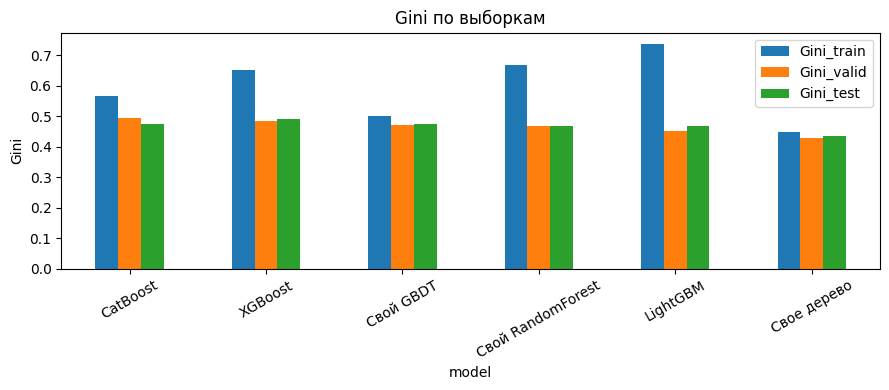

In [46]:
final_table.set_index('model')[['Gini_train', 'Gini_valid', 'Gini_test']].plot(kind='bar', rot=30, figsize=(9, 4), title='Gini по выборкам'); plt.ylabel('Gini'); plt.tight_layout(); plt.show()

**Есть ли переобучение?**

Картина не такая однозначная, как можно было бы ожидать. Свое дерево (глубина всего 3, подобрана по
validation) и свой GBDT дают самый маленький overfit_gap (0.019 и 0.028) - они и не должны переобучаться
сильно, так как дерево неглубокое, а GBDT использует раннюю остановку по best_iter. А вот у своего
RandomForest (0.202) и особенно у LightGBM (0.285) разрыв самый большой — несмотря на раннюю остановку
у LightGBM, ее оказалось недостаточно при параметрах по умолчанию. Значит "бустинг = меньше переобучения"
не универсальное правило, тут важны конкретные гиперпараметры регуляризации.

Что касается valid_test_drop - у большинства моделей (кроме CatBoost) он отрицательный: качество на
test не упало, а слегка выросло. Здесь падения как такового нет, поэтому дрейф данных во времени
в эту сторону не действует так однозначно, как можно было предположить - возможно, машины в тестовом
периоде оказались чуть более предсказуемыми. У лучшей модели (CatBoost) разрыв valid test небольшой
(0.020), что говорит об умеренном и контролируемом переобучении

## Задание 9 (бонус). ExtraTreesClassifier

Extra Trees (Extremely Randomized Trees) отличается от случайного леса двумя вещами:

1. порог разбиения выбирается случайно, а не как наилучший (для этого в задании 2 мы написали
   отдельный метод `_find_random_split`)
2. по умолчанию не используется бутстрэп - каждое дерево учится на всей выборке.

Дополнительная случайность делает отдельные деревья слабее, но и менее скоррелированными между собой,
а усреднение некоррелированных ошибок работает лучше. Плюс обучение быстрее, ведь искать оптимальный
порог не нужно.

меняются только два атрибута класса,
весь остальной код переиспользуется

In [47]:
class MyExtraTreesClassifier(MyRandomForestClassifier):
    splitter, default_bootstrap = 'random', False

In [48]:
start = time.perf_counter()
my_extra = MyExtraTreesClassifier(n_estimators=50, max_depth=9, max_features='sqrt', min_samples_leaf=20, random_state=RANDOM_STATE).fit(X_train, y_train)
extra_gini = gini(y_valid, my_extra.predict_proba(X_valid)[:, 1])
print('Gini на validation:', round(extra_gini, 4), '| порог 0.12 пройден:', extra_gini >= 0.12, '| время:', round(time.perf_counter() - start, 1), 'сек')

Gini на validation: 0.4724 | порог 0.12 пройден: True | время: 18.4 сек


In [49]:
pd.DataFrame([{'model': 'Одно дерево', 'Gini_valid': my_tree_gini},
              {'model': 'Свой RandomForest', 'Gini_valid': forest_gini},
              {'model': 'Свой ExtraTrees', 'Gini_valid': extra_gini},
              {'model': 'sklearn ExtraTrees', 'Gini_valid': gini(y_valid, SkExtraTreesClassifier(n_estimators=50, max_depth=9, max_features='sqrt', min_samples_leaf=20, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train).predict_proba(X_valid)[:, 1])}]).round(4)

,model,Gini_valid
0,Одно дерево,0.4286
1,Свой RandomForest,0.4675
2,Свой ExtraTrees,0.4724
3,sklearn ExtraTrees,0.4660


ExtraTrees уверенно обходит одиночное дерево. По сравнению с обычным лесом результат может быть как
чуть лучше, так и чуть хуже - это зависит от данных: случайные пороги сильнее регуляризуют модель,
что помогает на шумных данных и мешает, когда сигнал хорошо ловится точными порогами